In [1]:
#import sys
#!{sys.executable} -m pip install pyLDAvis


LDA Topics (K=2)

Topic 0: ai, cent, day, saks, change, business, software, google, openai, world, data, close

Topic 1: cls, bank, china, holdings, energy, corp, technologies, stock, week, price, eur, united

Saved: lda_doc_topics.csv

FinBERT sentiment by topic
   topic  count      mean    median       std  \
0      0     59  0.410418  0.394187  0.350107   
1      1     40  0.899588  0.899662  0.004018   

                                           top_words  
0  ai, cent, day, saks, change, business, softwar...  
1  cls, bank, china, holdings, energy, corp, tech...  

Saved: lda_sentiment_by_topic.csv


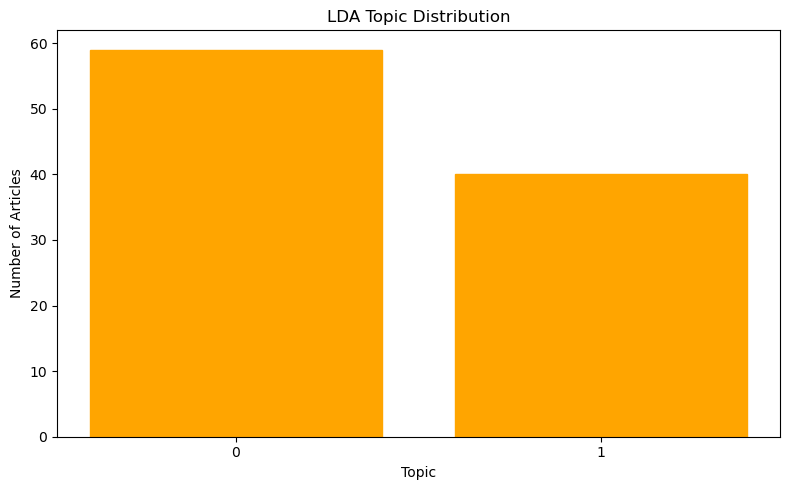

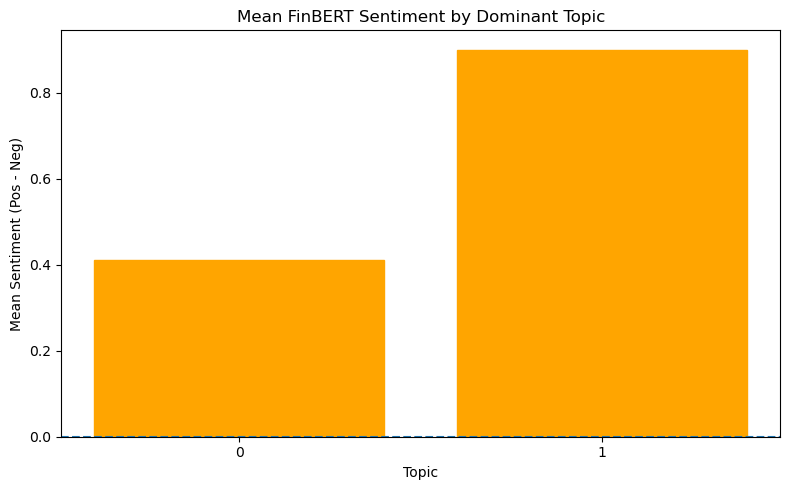


Saved: lda_visualisation.html (open in your browser)


In [2]:
# -*- coding: utf-8 -*-
"""
LDA Topics + pyLDAvis HTML + FinBERT sentiment by topic (NO pyLDAvis.sklearn)

Reads:  ft_nvidia_sentiment.csv  (needs: text, sentiment_score)
Writes:
  - lda_doc_topics.csv
  - lda_sentiment_by_topic.csv
  - lda_visualisation.html
Also:
  - prints top words per topic
  - plots topic prevalence + mean sentiment by topic
"""

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import pyLDAvis


# ----------------------------
# Config
# ----------------------------
INPUT_CSV = "ft_salesforce_sentiment.csv"
N_TOPICS =2
N_TOP_WORDS = 12

MAX_FEATURES = 5000
MIN_DF = 3
MAX_DF = 0.7


# ----------------------------
# Load
# ----------------------------
df = pd.read_csv(INPUT_CSV)
if "text" not in df.columns or "sentiment_score" not in df.columns:
    raise ValueError("CSV must contain 'text' and 'sentiment_score' columns.")


# ----------------------------
# Clean text (possessive fix)
# ----------------------------
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"'s\b", "", text)      # remove possessives: company's -> company
    text = text.replace("'", " ")
    text = re.sub(r"[^a-z\s]", " ", text) # letters/spaces only
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)


# ----------------------------
# Vectorise (bag-of-words)
# ----------------------------
extra_stop = {
    "salesforce", "srm", "ft", "financial", "times",
    "said", "say", "says", "according", "told",
    "mr", "ms", "bn", "mn", "tn",
    "company", "companies", "year", "years"
}

# Use sklearn english stopwords + our extras
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=MAX_FEATURES,
    min_df=MIN_DF,
    max_df=MAX_DF
)

X = vectorizer.fit_transform(df["clean_text"])
feature_names = vectorizer.get_feature_names_out()

# Remove extra_stop from the already-built vocab/matrix (explicit & simple)
keep_mask = ~np.isin(feature_names, list(extra_stop))
X = X[:, keep_mask]
feature_names = feature_names[keep_mask]


# ----------------------------
# Fit LDA
# ----------------------------
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method="batch"
)
doc_topic = lda.fit_transform(X)  # (n_docs x n_topics)


# ----------------------------
# Print top words per topic
# ----------------------------
print("\n===============================")
print(f"LDA Topics (K={N_TOPICS})")
print("===============================")

topic_topwords = {}
for k, topic_weights in enumerate(lda.components_):
    top_idx = topic_weights.argsort()[::-1][:N_TOP_WORDS]
    top_terms = feature_names[top_idx]
    topic_topwords[k] = ", ".join(top_terms)
    print(f"\nTopic {k}: {topic_topwords[k]}")


# ----------------------------
# Assign dominant topic + save doc-topic matrix
# ----------------------------
df["dominant_topic"] = doc_topic.argmax(axis=1)
for k in range(N_TOPICS):
    df[f"topic_{k}"] = doc_topic[:, k]

df.to_csv("lda_doc_topics.csv", index=False)
print("\nSaved: lda_doc_topics.csv")


# ----------------------------
# FinBERT sentiment by topic
# ----------------------------
sent_summary = (
    df.groupby("dominant_topic")["sentiment_score"]
      .agg(["count", "mean", "median", "std"])
      .reset_index()
      .rename(columns={"dominant_topic": "topic"})
)
sent_summary["top_words"] = sent_summary["topic"].map(topic_topwords)
sent_summary.to_csv("lda_sentiment_by_topic.csv", index=False)

print("\n===============================")
print("FinBERT sentiment by topic")
print("===============================")
print(sent_summary)
print("\nSaved: lda_sentiment_by_topic.csv")


# ----------------------------
# Plot: topic prevalence
# ----------------------------
topic_counts = df["dominant_topic"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(
    topic_counts.index,
    topic_counts.values,
    color="orange",     # dark orange
    edgecolor="orange"
)
plt.xlabel("Topic")
plt.ylabel("Number of Articles")
plt.title("LDA Topic Distribution")
plt.xticks(range(N_TOPICS))
plt.tight_layout()
plt.show()


# ----------------------------
# Plot: mean sentiment by topic
# ----------------------------
plt.figure(figsize=(8, 5))
plt.bar(
    sent_summary["topic"],
    sent_summary["mean"],
    color="orange",
    edgecolor="orange"
)
plt.axhline(0, linestyle="--")
plt.xlabel("Topic")
plt.ylabel("Mean Sentiment (Pos - Neg)")
plt.title("Mean FinBERT Sentiment by Dominant Topic")
plt.xticks(range(N_TOPICS))
plt.tight_layout()
plt.show()


# ----------------------------
# pyLDAvis interactive HTML (no pyLDAvis.sklearn)
# ----------------------------
# pyLDAvis.prepare expects:
# - topic_term_dists: (K x V) topic-word weights
# - doc_topic_dists:  (D x K) document-topic probabilities
# - doc_lengths:      (D,) document lengths in tokens (bag-of-words counts)
# - vocab:            (V,) vocabulary terms
# - term_frequency:   (V,) corpus term counts
vis = pyLDAvis.prepare(
    topic_term_dists=lda.components_,
    doc_topic_dists=doc_topic,
    doc_lengths=X.sum(axis=1).A1,
    vocab=feature_names,
    term_frequency=X.sum(axis=0).A1
)

pyLDAvis.save_html(vis, "lda_visualisation.html")
print("\nSaved: lda_visualisation.html (open in your browser)")